In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
df = pd.read_csv("/Users/jonathanzhu/nematostella_videos/imgs/rpa_bb_16C_9_dpf_celldish_04_02_2026/positions.csv", index_col=0)
df.head()

,image_filename,x1,y1,x2,y2,conf,class
0,/Users/jonathanzhu/nematostella_videos/imgs/rp...,459.16450,600.93000,485.07820,612.59000,0.957247,1.0
1,/Users/jonathanzhu/nematostella_videos/imgs/rp...,772.72614,484.01890,788.78710,506.91350,0.954870,1.0
2,/Users/jonathanzhu/nematostella_videos/imgs/rp...,760.34620,541.13890,773.05290,551.60410,0.934535,0.0
3,/Users/jonathanzhu/nematostella_videos/imgs/rp...,197.46588,686.65485,214.34150,698.35130,0.918712,1.0
4,/Users/jonathanzhu/nematostella_videos/imgs/rp...,546.09340,634.06280,565.46716,645.74567,0.914138,1.0


In [3]:
df.shape

(38700, 7)

In [4]:
filenames = df["image_filename"].unique()

In [5]:
df[df.image_filename == filenames[0]]

,image_filename,x1,y1,x2,y2,conf,class
0,/Users/jonathanzhu/nematostella_videos/imgs/rp...,459.16450,600.93000,485.078200,612.59000,0.957247,1.0
1,/Users/jonathanzhu/nematostella_videos/imgs/rp...,772.72614,484.01890,788.787100,506.91350,0.954870,1.0
2,/Users/jonathanzhu/nematostella_videos/imgs/rp...,760.34620,541.13890,773.052900,551.60410,0.934535,0.0
3,/Users/jonathanzhu/nematostella_videos/imgs/rp...,197.46588,686.65485,214.341500,698.35130,0.918712,1.0
4,/Users/jonathanzhu/nematostella_videos/imgs/rp...,546.09340,634.06280,565.467160,645.74567,0.914138,1.0
5,/Users/jonathanzhu/nematostella_videos/imgs/rp...,394.71576,847.53644,405.710330,867.14120,0.912374,1.0
6,/Users/jonathanzhu/nematostella_videos/imgs/rp...,188.88647,267.71155,201.018830,284.14807,0.905316,0.0
7,/Users/jonathanzhu/nematostella_videos/imgs/rp...,192.92340,747.96370,202.907410,758.84320,0.904230,0.0
8,/Users/jonathanzhu/nematostella_videos/imgs/rp...,697.33130,865.95000,707.776600,877.05810,0.903141,0.0
9,/Users/jonathanzhu/nematostella_videos/imgs/rp...,789.45280,370.50280,798.999150,380.36017,0.902503,0.0


In [7]:
df_individuals = []
for f in filenames:
    df_individuals.append(df[df.image_filename == f])

df_individuals

[                                       image_filename         x1         y1  \
 0   /Users/jonathanzhu/nematostella_videos/imgs/rp...  459.16450  600.93000   
 1   /Users/jonathanzhu/nematostella_videos/imgs/rp...  772.72614  484.01890   
 2   /Users/jonathanzhu/nematostella_videos/imgs/rp...  760.34620  541.13890   
 3   /Users/jonathanzhu/nematostella_videos/imgs/rp...  197.46588  686.65485   
 4   /Users/jonathanzhu/nematostella_videos/imgs/rp...  546.09340  634.06280   
 5   /Users/jonathanzhu/nematostella_videos/imgs/rp...  394.71576  847.53644   
 6   /Users/jonathanzhu/nematostella_videos/imgs/rp...  188.88647  267.71155   
 7   /Users/jonathanzhu/nematostella_videos/imgs/rp...  192.92340  747.96370   
 8   /Users/jonathanzhu/nematostella_videos/imgs/rp...  697.33130  865.95000   
 9   /Users/jonathanzhu/nematostella_videos/imgs/rp...  789.45280  370.50280   
 10  /Users/jonathanzhu/nematostella_videos/imgs/rp...  408.30728  552.89343   
 11  /Users/jonathanzhu/nematostella_vid

In [8]:
len(df_individuals)

1799

In [9]:
df_lens = [len(x) for x in df_individuals]
df_lens

[21,
 23,
 22,
 21,
 22,
 24,
 22,
 22,
 22,
 23,
 21,
 23,
 22,
 22,
 23,
 23,
 21,
 21,
 20,
 20,
 21,
 20,
 21,
 21,
 22,
 21,
 22,
 21,
 23,
 23,
 21,
 23,
 21,
 22,
 21,
 21,
 21,
 21,
 21,
 22,
 20,
 20,
 21,
 20,
 20,
 21,
 21,
 21,
 21,
 22,
 20,
 22,
 21,
 22,
 20,
 22,
 23,
 20,
 23,
 21,
 20,
 22,
 22,
 20,
 21,
 21,
 22,
 21,
 22,
 21,
 22,
 20,
 20,
 22,
 21,
 20,
 21,
 21,
 22,
 22,
 21,
 23,
 21,
 21,
 21,
 23,
 24,
 23,
 21,
 21,
 23,
 21,
 21,
 19,
 21,
 21,
 21,
 19,
 20,
 22,
 21,
 21,
 23,
 23,
 21,
 22,
 22,
 23,
 24,
 22,
 23,
 21,
 22,
 21,
 20,
 24,
 21,
 23,
 23,
 22,
 21,
 23,
 21,
 22,
 22,
 23,
 23,
 21,
 23,
 22,
 22,
 21,
 19,
 21,
 19,
 20,
 21,
 21,
 21,
 21,
 19,
 21,
 21,
 23,
 22,
 24,
 23,
 21,
 21,
 22,
 21,
 22,
 22,
 22,
 20,
 20,
 20,
 21,
 20,
 20,
 21,
 21,
 21,
 22,
 21,
 22,
 21,
 20,
 20,
 22,
 21,
 21,
 22,
 21,
 22,
 22,
 22,
 22,
 21,
 22,
 20,
 21,
 21,
 22,
 20,
 21,
 21,
 20,
 22,
 22,
 22,
 22,
 21,
 23,
 22,
 21,
 23,
 23,
 23,
 21,


(array([  1.,  38., 240., 701., 510., 222.,  68.,  13.,   6.,   0.]),
 array([17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5]),
 <BarContainer object of 10 artists>)

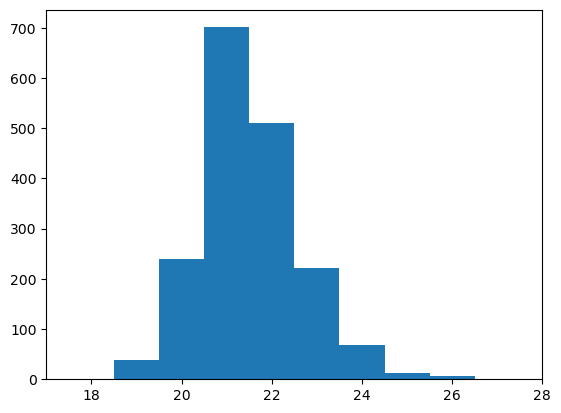

In [10]:
plt.hist(df_lens, bins = [17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5])

In [11]:
#read filter image as numpy array
filter = cv2.imread("/Users/jonathanzhu/nematostella_videos/imgs/rpa_bb_16C_9_dpf_celldish_04_02_2026/rpa_bb_16C_9_dpf_celldish_04_02_2026_filter.png")

In [12]:
#if the prediction's (x1, y1) or (x2, y2) lands in the white portion of the filter, ignore it
#to help us out, a helper function that checks if true
def point_in_filter(x, y, filter):
    #check only the first slice, hence [0]
    if filter[int(x), int(y)][0] == 255:
        return True
    else:
        return False

In [14]:
#drop row of all dataframes where x1, y1 in filter OR x2, y2 in filter
df_individuals_filtered = df_individuals
for i in range(len(df_individuals_filtered)):
    print(i)
    labs = []
    df_temp = df_individuals_filtered[i]
    for j in range(len(df_temp)):
        if point_in_filter(df_temp.iloc[j]["x1"], df_temp.iloc[j]["y1"], filter):
            labs.append(True)
        elif point_in_filter(df_temp.iloc[j]["x2"], df_temp.iloc[j]["y2"], filter):
            labs.append(True)
        else:
            labs.append(False)

    df_temp.insert(1, "in_filter", labs)
    df_individuals_filtered[i] = df_temp[df_temp.in_filter == False]
    
df_lens = [len(x) for x in df_individuals_filtered]
df_lens

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

[21,
 23,
 22,
 21,
 22,
 24,
 22,
 21,
 21,
 23,
 21,
 23,
 22,
 22,
 23,
 23,
 21,
 21,
 20,
 20,
 21,
 20,
 21,
 21,
 22,
 21,
 21,
 21,
 23,
 23,
 21,
 23,
 20,
 22,
 21,
 21,
 20,
 20,
 21,
 22,
 20,
 20,
 21,
 20,
 20,
 21,
 21,
 21,
 21,
 22,
 20,
 22,
 21,
 22,
 20,
 22,
 23,
 20,
 23,
 21,
 20,
 22,
 22,
 20,
 21,
 21,
 22,
 21,
 22,
 21,
 22,
 20,
 20,
 22,
 21,
 20,
 20,
 21,
 22,
 22,
 20,
 23,
 21,
 21,
 20,
 23,
 24,
 23,
 20,
 21,
 23,
 21,
 21,
 19,
 21,
 21,
 21,
 19,
 20,
 22,
 21,
 21,
 23,
 23,
 21,
 22,
 21,
 23,
 24,
 21,
 23,
 21,
 22,
 21,
 20,
 24,
 21,
 23,
 23,
 22,
 21,
 23,
 21,
 21,
 21,
 23,
 23,
 21,
 23,
 22,
 22,
 21,
 19,
 21,
 19,
 20,
 21,
 21,
 21,
 21,
 19,
 21,
 21,
 23,
 21,
 24,
 22,
 21,
 21,
 22,
 21,
 22,
 21,
 22,
 20,
 20,
 20,
 21,
 20,
 20,
 21,
 21,
 21,
 22,
 21,
 22,
 21,
 20,
 20,
 22,
 21,
 21,
 22,
 21,
 22,
 22,
 22,
 22,
 21,
 22,
 20,
 21,
 21,
 22,
 20,
 21,
 21,
 20,
 20,
 22,
 22,
 22,
 20,
 23,
 22,
 21,
 23,
 23,
 23,
 20,


(array([ 20.,  84., 283., 707., 455., 193.,  48.,   5.,   4.,   0.]),
 array([17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5]),
 <BarContainer object of 10 artists>)

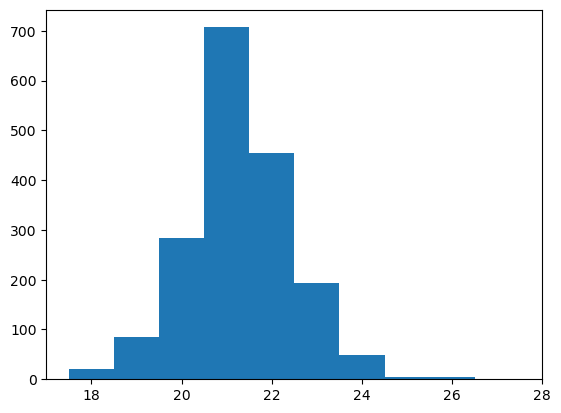

In [15]:
plt.hist(df_lens, bins = [17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5])

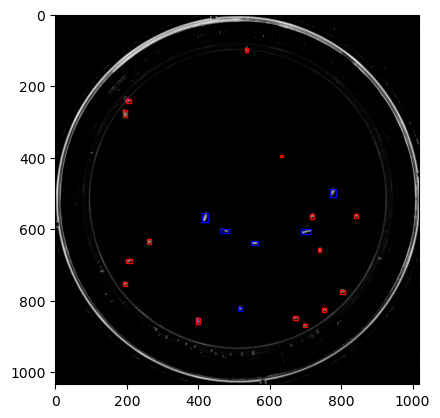

In [ ]:
#plot an image with its bounding boxes: show an example of how some false positives are introduced
img_test = plt.imread("/Users/jonathanzhu/nematostella_videos/imgs/rpa_bb_16C_9_dpf_celldish_04_02_2026/rpa_bb_16C_9_dpf_celldish_04_02_20260100.png")
df_test = df[df.image_filename == "/Users/jonathanzhu/nematostella_videos/imgs/rpa_bb_16C_9_dpf_celldish_04_02_2026/rpa_bb_16C_9_dpf_celldish_04_02_20260100.png"]

fig, ax = plt.subplots()
ax.imshow(img_test, cmap="gray")
for i in range(len(df_test)):
    w = df_test.iloc[i]["x2"] - df_test.iloc[i]["x1"]
    h = df_test.iloc[i]["y2"] - df_test.iloc[i]["y1"]
    x = df_test.iloc[i]["x2"] - w
    y = df_test.iloc[i]["y2"] - h
    if df_test.iloc[i]["class"] == 0.0: #label planula as red
        rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none')
    else: #label polyp as blue
        rect = plt.Rectangle((x, y), w, h, edgecolor='b', facecolor='none')
    ax.add_patch(rect)

plt.show()
    